# Makemore Part 2 — MLP Language Model

This notebook builds a **Multi-Layer Perceptron (MLP)** character-level language model, following Bengio et al. (2003): *A Neural Probabilistic Language Model*.

The core idea is to improve over the bigram model by using a **context window of 3 characters** instead of just 1, feeding them through an embedding table and a hidden layer to predict the next character.

| Feature | Part 1 (Bigram) | Part 2 (MLP) |
|---|---|---|
| Context window | 1 character | 3 characters |
| Architecture | Single weight matrix | Embedding + Hidden layer + Output |
| Parameters | ~729 | ~11,897 |
| Output quality | Basic | Much more name-like |

**Topics covered:**
- Building a dataset with a sliding context window
- Character embeddings as a learned lookup table
- MLP with one hidden layer and tanh activation
- Train / validation / test splits
- Mini-batch gradient descent
- Learning rate search and decay schedule
- Autoregressive text sampling

## 1.  Imports

Standard imports: PyTorch for tensors and autograd, matplotlib for plotting, random for dataset shuffling.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

%matplotlib inline

## 2.  Load Dataset and Build Vocabulary

We read all names from names.txt and build character-to-index (stoi) and index-to-character (itos) mappings.
The special token '.' at index 0 serves as both the start and end marker for each name.

In [2]:
# Read all names from file, one per line
words = open('names.txt', 'r').read().splitlines()
print(words[:8])
print(f'Total words: {len(words)}')

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
Total words: 32033


In [3]:
# Build vocabulary: sorted unique characters + special '.' token
chars = sorted(list(set(''.join(words))))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}  # 'a'->1, 'b'->2, ..., 'z'->26
stoi['.'] = 0                                       # '.' is the boundary token at index 0
itos = {i: ch for ch, i in stoi.items()}            # reverse mapping: index -> character

vocab_size = len(stoi)
print(itos)
print(f'Vocabulary size: {vocab_size}')             # should be 27

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
Vocabulary size: 27


## 3.  Build the Dataset with a Sliding Context Window

Instead of bigrams (1 character in, 1 out), we now use a context of block_size=3 characters to predict the next one.
The context window slides forward one character at a time through each word, padded at the start with '.' tokens.

Example for 'emma' with block_size=3:
```
Context  -->  Target
  ...    -->  e
  ..e    -->  m
  .em    -->  m
  emm    -->  a
  mma    -->  .
```

In [4]:
block_size = 3  # how many past characters are used to predict the next one

def build_dataset(word_list):
    """
    Build (X, Y) tensors from a list of words.
    X: integer context indices of shape (N, block_size)
    Y: integer target indices of shape (N,)
    """
    X_data, Y_data = [], []
    for word in word_list:
        ctx = [0] * block_size                # pad context with '.' tokens
        for ch in word + '.':
            idx = stoi[ch]
            X_data.append(ctx)
            Y_data.append(idx)
            ctx = ctx[1:] + [idx]             # slide the window forward by one
    X_data = torch.tensor(X_data)
    Y_data = torch.tensor(Y_data)
    print(X_data.shape, Y_data.shape)
    return X_data, Y_data

## 4.  Train / Validation / Test Split

We shuffle words randomly then split into three sets:
- **Train (80%)**: used to update model weights
- **Validation (10%)**: used to monitor overfitting during development
- **Test (10%)**: held out and only evaluated at the very end

In [5]:
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))   # 80% for training
n2 = int(0.9 * len(words))   # next 10% for validation

Xtr,  Ytr  = build_dataset(words[:n1])    # training split
Xdev, Ydev = build_dataset(words[n1:n2])  # validation split
Xte,  Yte  = build_dataset(words[n2:])    # test split

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## 5.  Model Parameters

The MLP has three sets of learnable parameters:

- **C** — embedding table of shape (vocab_size, n_embd). Each character gets a dense vector representation.
- **W1, b1** — hidden layer weights and biases. Input size is block_size * n_embd  (flattened context embeddings).
- **W2, b2** — output layer weights and biases. Produces a logit score for each character in the vocabulary.

All parameters need requires_grad=True so PyTorch can compute gradients during backpropagation.

In [6]:
g = torch.Generator().manual_seed(2147483647)  # fixed seed for reproducibility

n_embd   = 10   # embedding dimension per character
n_hidden = 200  # number of neurons in the hidden layer

# Embedding lookup table
C  = torch.randn((vocab_size, n_embd),            generator=g)

# Hidden layer: input is the concatenation of block_size embeddings
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)

# Output layer: produces one logit per character in vocab
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, b1, W2, b2]

# Enable gradient tracking on all parameters
for p in parameters:
    p.requires_grad = True

total_params = sum(p.nelement() for p in parameters)
print(f'Total trainable parameters: {total_params}')

Total trainable parameters: 11897


## 6.  Learning Rate Search

Before committing to a fixed learning rate, we sweep across a range of values on a log scale and record the loss at each step.
The best learning rate is where the loss drops fastest — just before it starts to diverge or plateau.

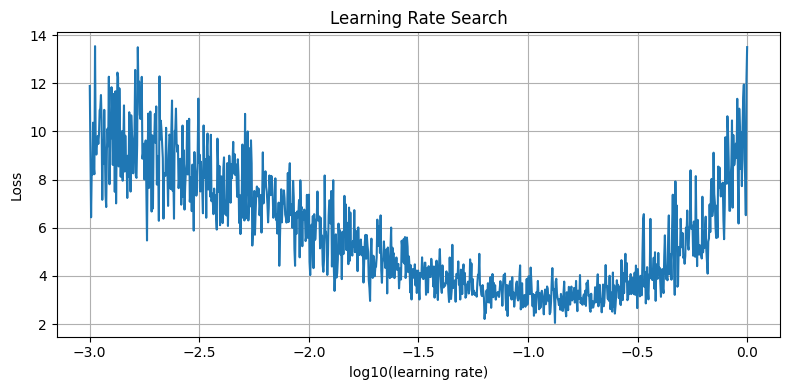

In [15]:
# Log-spaced learning rate candidates from 1e-3 to 1.0
lr_exponents = torch.linspace(-3, 0, 1000)
lr_candidates = 10 ** lr_exponents

lr_log   = []   # record the log10(lr) at each step
loss_log = []   # record the loss at each step

for i in range(1000):
    # Sample a random mini-batch
    batch_idx = torch.randint(0, Xtr.shape[0], (32,))

    # Forward pass
    emb    = C[Xtr[batch_idx]]                                          # (32, block_size, n_embd)
    hidden = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)  # (32, n_hidden)
    logits = hidden @ W2 + b2                                           # (32, vocab_size)
    loss   = F.cross_entropy(logits, Ytr[batch_idx])

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update with the current candidate learning rate
    current_lr = lr_candidates[i].item()
    for p in parameters:
        p.data -= current_lr * p.grad

    lr_log.append(lr_exponents[i].item())
    loss_log.append(loss.item())

plt.figure(figsize=(8, 4))
plt.plot(lr_log, loss_log)
plt.xlabel('log10(learning rate)')
plt.ylabel('Loss')
plt.title('Learning Rate Search')
plt.grid(True)
plt.tight_layout()
# The loss should drop around log10(lr) = -1, i.e. lr ~ 0.1

## 7.  Training Loop with Mini-Batch SGD

We reinitialise the parameters and train for 200,000 steps using mini-batch stochastic gradient descent.

Key design choices:
- **Batch size = 32**: randomly sampled each step — fast and introduces useful gradient noise.
- **F.cross_entropy**: numerically stable; combines log-softmax and NLL loss in one call.
- **Learning rate decay**: start at 0.1 for the first 100k steps, then drop to 0.01 to fine-tune.

In [8]:
# Reinitialise parameters cleanly before the real training run
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

print(f'Total trainable parameters: {sum(p.nelement() for p in parameters)}')

Total trainable parameters: 11897


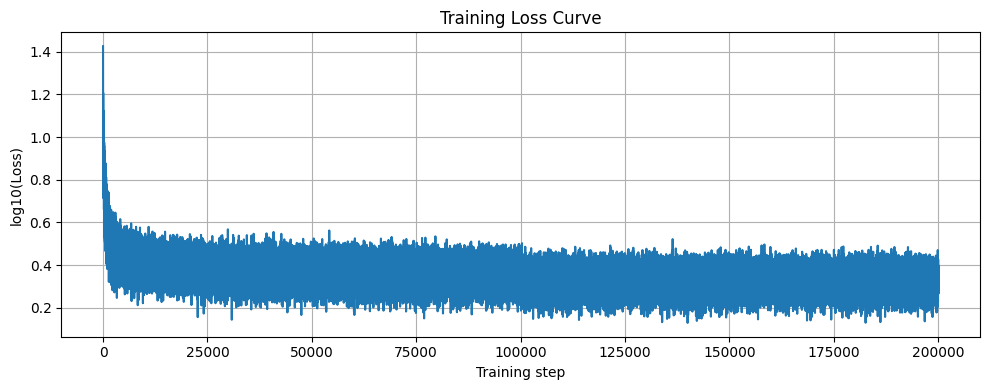

In [9]:
max_steps  = 200000
batch_size = 32
step_log   = []
loss_log   = []

for i in range(max_steps):

    # Mini-batch construction
    batch_idx = torch.randint(0, Xtr.shape[0], (batch_size,))

    # Forward pass
    emb    = C[Xtr[batch_idx]]                                          # (batch, block_size, n_embd)
    hidden = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)  # (batch, n_hidden)
    logits = hidden @ W2 + b2                                           # (batch, vocab_size)
    loss   = F.cross_entropy(logits, Ytr[batch_idx])                   # scalar

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Learning rate schedule: decay after 100k steps
    lr = 0.1 if i < 100000 else 0.01

    # Parameter update
    for p in parameters:
        p.data -= lr * p.grad

    step_log.append(i)
    loss_log.append(loss.log10().item())   # log10 loss for a smoother plot

# Plot the training loss curve
plt.figure(figsize=(10, 4))
plt.plot(step_log, loss_log)
plt.xlabel('Training step')
plt.ylabel('log10(Loss)')
plt.title('Training Loss Curve')
plt.grid(True)
plt.tight_layout()

## 8. Evaluate on Train and Validation Sets

After training we measure loss on the full training and validation splits.
- If train loss is much lower than val loss: **overfitting**.
- If both losses are similarly high: **underfitting**.

In [10]:
# Evaluate on the full training split
emb    = C[Xtr]
hidden = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = hidden @ W2 + b2
train_loss = F.cross_entropy(logits, Ytr)
print(f'Training loss  : {train_loss.item():.4f}')

Training loss  : 2.1315


In [11]:
# Evaluate on the validation split
emb    = C[Xdev]
hidden = torch.tanh(emb.view(-1, block_size * n_embd) @ W1 + b1)
logits = hidden @ W2 + b2
val_loss = F.cross_entropy(logits, Ydev)
print(f'Validation loss: {val_loss.item():.4f}')

Validation loss: 2.1694


## 9.  Visualise Learned Character Embeddings

We plot the first two dimensions of the embedding matrix C to see how the model has organised characters in 2D space.
Characters that appear in similar contexts during training tend to cluster together.

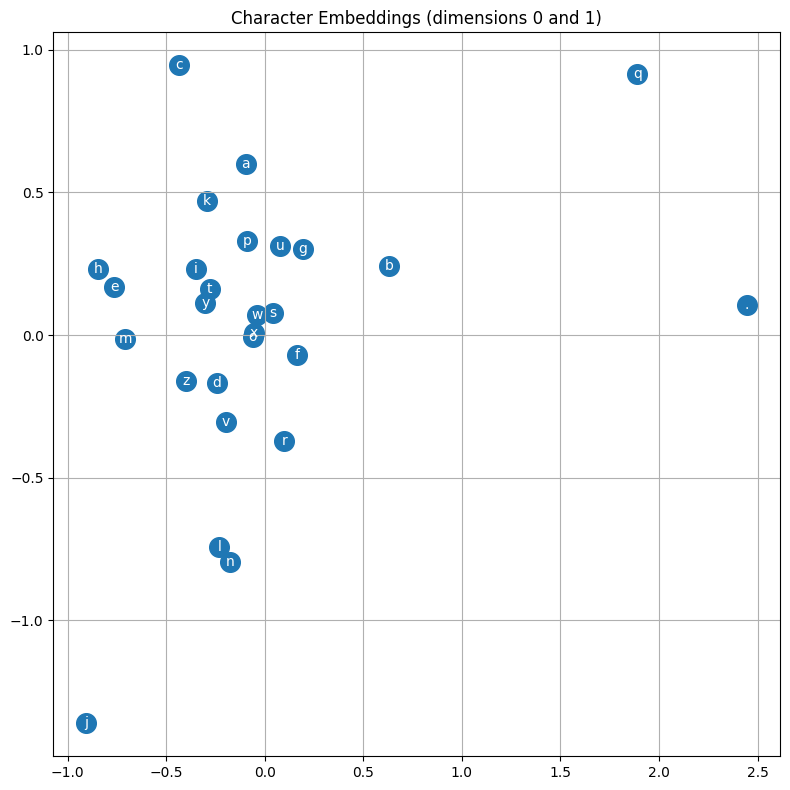

In [12]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(vocab_size):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i],
             ha='center', va='center', color='white')
plt.title('Character Embeddings (dimensions 0 and 1)')
plt.grid('minor')
plt.tight_layout()

## 10.  Sample Names from the Trained Model

Autoregressive sampling: start with all '.' context tokens, run a forward pass, sample the next character, slide the window, and repeat until the '.' end token is generated.

In [13]:
# Sample 20 names from the trained model
g_sample = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    ctx = [0] * block_size               # initialise with all '.' padding
    while True:
        emb    = C[torch.tensor([ctx])]  # (1, block_size, n_embd)
        hidden = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = hidden @ W2 + b2
        probs  = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g_sample).item()
        ctx = ctx[1:] + [ix]             # slide context window
        out.append(ix)
        if ix == 0:                      # stop when end token is generated
            break
    print(''.join(itos[i] for i in out))

carlah.
amille.
khyemili.
tatyah.
cassie.
rahnen.
delynn.
pareei.
nellara.
chaiir.
kaleigh.
ham.
pris.
quinn.
sulin.
alvin.
quinzero.
dearyxi.
frae.
pirran.
